In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [60]:
url="https://gist.githubusercontent.com/semicolonSimp/b379995207163d47dbc6c3adb8f5dac7/raw/f68a4cddfdbe72f11245d00476a85f1b6dc01a03/bike%2520price%2520prediction"
df=pd.read_csv(url) 
df.head()
df.shape

(308, 10)

In [61]:
df.head(5)

,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,CC(Cubic capacity),Fuel_Capacity,Price
0,1,Bajaj,Avenger 220,2020,5.0,Single,Petrol,220CC,10 Litres,113000
1,2,TVS,Apache RTR,2020,5.0,V-twin,Petrol,120CC,11 Litres,70000
2,3,Hero,Passion,2020,5.0,Boxer,Petrol,140CC,12 Litres,85000
3,4,Honda,Activa 3G,2020,5.0,Single,Petrol,150CC,13 Litres,90000
4,5,Suzuki,Access,2020,5.0,V-twin,Petrol,350CC,14 Litres,65000


In [62]:
df.isnull().sum()
df.describe()

,S.no,Manufactured_year,Engine_warranty,Price
count,308.000000,308.000000,306.000000,3.080000e+02
mean,154.496753,2010.847403,6.032680,2.548416e+05
std,89.059088,104.747343,3.719542,2.950174e+05
min,1.000000,202.000000,2.000000,5.000000e+04
25%,77.750000,2017.000000,4.000000,7.500000e+04
50%,154.500000,2019.000000,5.000000,1.045000e+05
75%,231.250000,2020.000000,8.000000,3.412500e+05
max,308.000000,2050.000000,50.000000,1.779990e+06


In [63]:
cat=df.select_dtypes(include='object').columns
num=df.select_dtypes(exclude='object').columns

In [64]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
df[num] = num_imp.fit_transform(df[num])

In [65]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[cat] = cat_imp.fit_transform(df[cat])

In [66]:
df['Fuel_Capacity'] = df['Fuel_Capacity'].replace('Battery', '0')
df['Fuel_Capacity'] = df['Fuel_Capacity'].str.replace('Litres', '', regex=False)
df['Fuel_Capacity'] = df['Fuel_Capacity'].astype(int)

In [67]:
df['CC(Cubic capacity)'] = df['CC(Cubic capacity)'].str.replace('CC', '', regex=False)
df['CC(Cubic capacity)'] = df['CC(Cubic capacity)'].astype(int)

In [68]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()#output come in one columns all diff category assign 0,1,2...
df["Fuel_type"] = le.fit_transform(df["Fuel_type"])
df['Engine_type'] = le.fit_transform(df['Engine_type'])


In [69]:
print(df['Bike_company'].nunique())
print(df['Bike_model'].nunique())

25
237


In [70]:
df = pd.get_dummies(df, columns=['Bike_company'], drop_first=True, dtype=int)

In [71]:
columns=["S.no","Price","Bike_model"]
X=df.drop(columns,axis=1)
y=df["Price"]

In [72]:
X.head(5)
X.shape

(308, 30)

<Axes: >

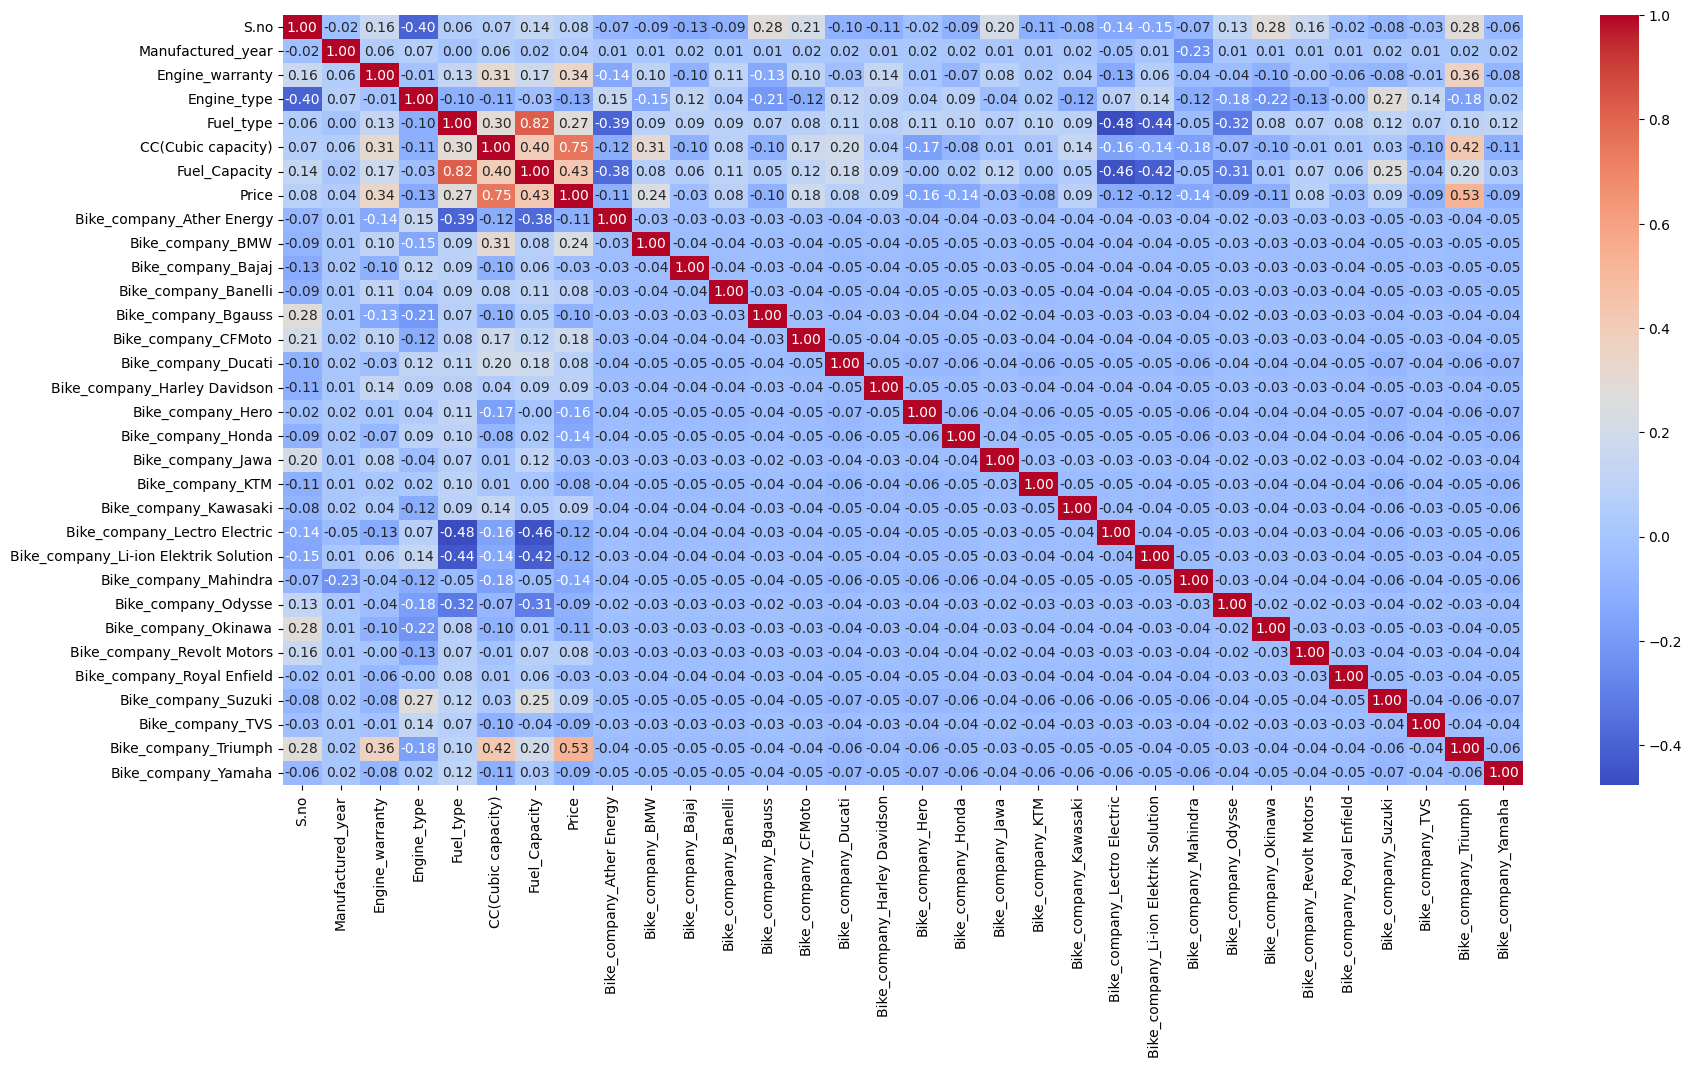

In [73]:
import seaborn as sns
num= df.select_dtypes(include="number")#sare numerical columns select kiye hue h
corr_matrix = num.corr()#correation matrix bnai

plt.figure(figsize=(20, 10))#size increase ke liye use kiya h
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",#2 float value tak aaye output
    cmap="coolwarm"
)


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test.head()

,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,CC(Cubic capacity),Fuel_Capacity,Bike_company_Ather Energy,Bike_company_BMW,Bike_company_Bajaj,Bike_company_Banelli,...,Bike_company_Li-ion Elektrik Solution,Bike_company_Mahindra,Bike_company_Odysse,Bike_company_Okinawa,Bike_company_Revolt Motors,Bike_company_Royal Enfield,Bike_company_Suzuki,Bike_company_TVS,Bike_company_Triumph,Bike_company_Yamaha
288,2020.0,6.0,0,1,155,16,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,2011.0,5.0,3,1,170,19,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
57,2017.0,4.0,0,1,390,15,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60,2017.0,3.0,0,1,300,18,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25,2015.0,5.0,0,1,125,17,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
X_test_scaled


array([[ 0.08825425,  0.00427885, -1.33462218, ..., -0.17113943,
        -0.24565184, -0.26375219],
       [ 0.01096196, -0.35045124,  0.18771347, ..., -0.17113943,
        -0.24565184, -0.26375219],
       [ 0.06249015, -0.70518133, -1.33462218, ..., -0.17113943,
        -0.24565184, -0.26375219],
       ...,
       [ 0.05390212,  1.42319921,  0.18771347, ..., -0.17113943,
        -0.24565184, -0.26375219],
       [ 0.08825425,  1.42319921, -1.33462218, ..., -0.17113943,
        -0.24565184, -0.26375219],
       [ 0.05390212, -0.35045124,  1.20260391, ..., -0.17113943,
        -0.24565184, -0.26375219]], shape=(62, 30))

## Linear Regression

In [77]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
y_pred


array([ 89400.08330985, 185453.88214704, 178875.81792284, 148127.13815272,
        85732.36927496,  44433.72508977, 441437.97734897, 402010.97699578,
       616821.05927664, 438966.34425747, 325582.34202077, 119435.10779565,
        94073.14507553, 100758.04852253,  86723.37609304, 127023.70900586,
       216504.84511708, 251110.5760819 ,  92642.94963929, 280596.0685907 ,
        54195.39416703,  87963.57782702, 222451.00352954, 111346.1560368 ,
        49390.83469319, 149649.85336489, 229290.20789325,  87234.93180333,
       243127.08351703, 454345.13947332, 119511.90900195, -34851.43012542,
        85875.2452497 , 853423.8288086 , 504065.67210282, 399560.21581577,
       432246.93075434, 177255.88588322, 116202.11790425, 408103.36012933,
       336311.73526405, 182671.44872973, 301444.46335693, 542069.92713568,
        44758.75025479, 234343.32035447, 259670.33584219, 113488.94938319,
        17136.10916322,  52653.10755063, 482359.79325531, 311193.27995138,
       271286.25088422, 1

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 91543.90025022611
MSE : 22151706849.222103
RMSE: 148834.4948230151
R2  : 0.6564902304152856


In [79]:

from sklearn.linear_model import LassoCV
a=[0.01,0.1,2,5,20,30,50,100]
lcv=LassoCV(
    alphas=a,
    max_iter=500,
    cv=5
)
lcv.fit(X_train,y_train)
y_pred=lcv.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 93258.3837231683
MSE : 22596620573.97149
RMSE: 150321.72355974198
R2  : 0.6495908879802306


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.227e+11, tolerance: 2.056e+09
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.327e+12, tolerance: 1.987e+09
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

In [80]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=3,max_leaf_nodes=25)
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))



MAE : 90184.4541184524
MSE : 25265731784.507927
RMSE: 158951.97949226026
R2  : 0.6082005886607202


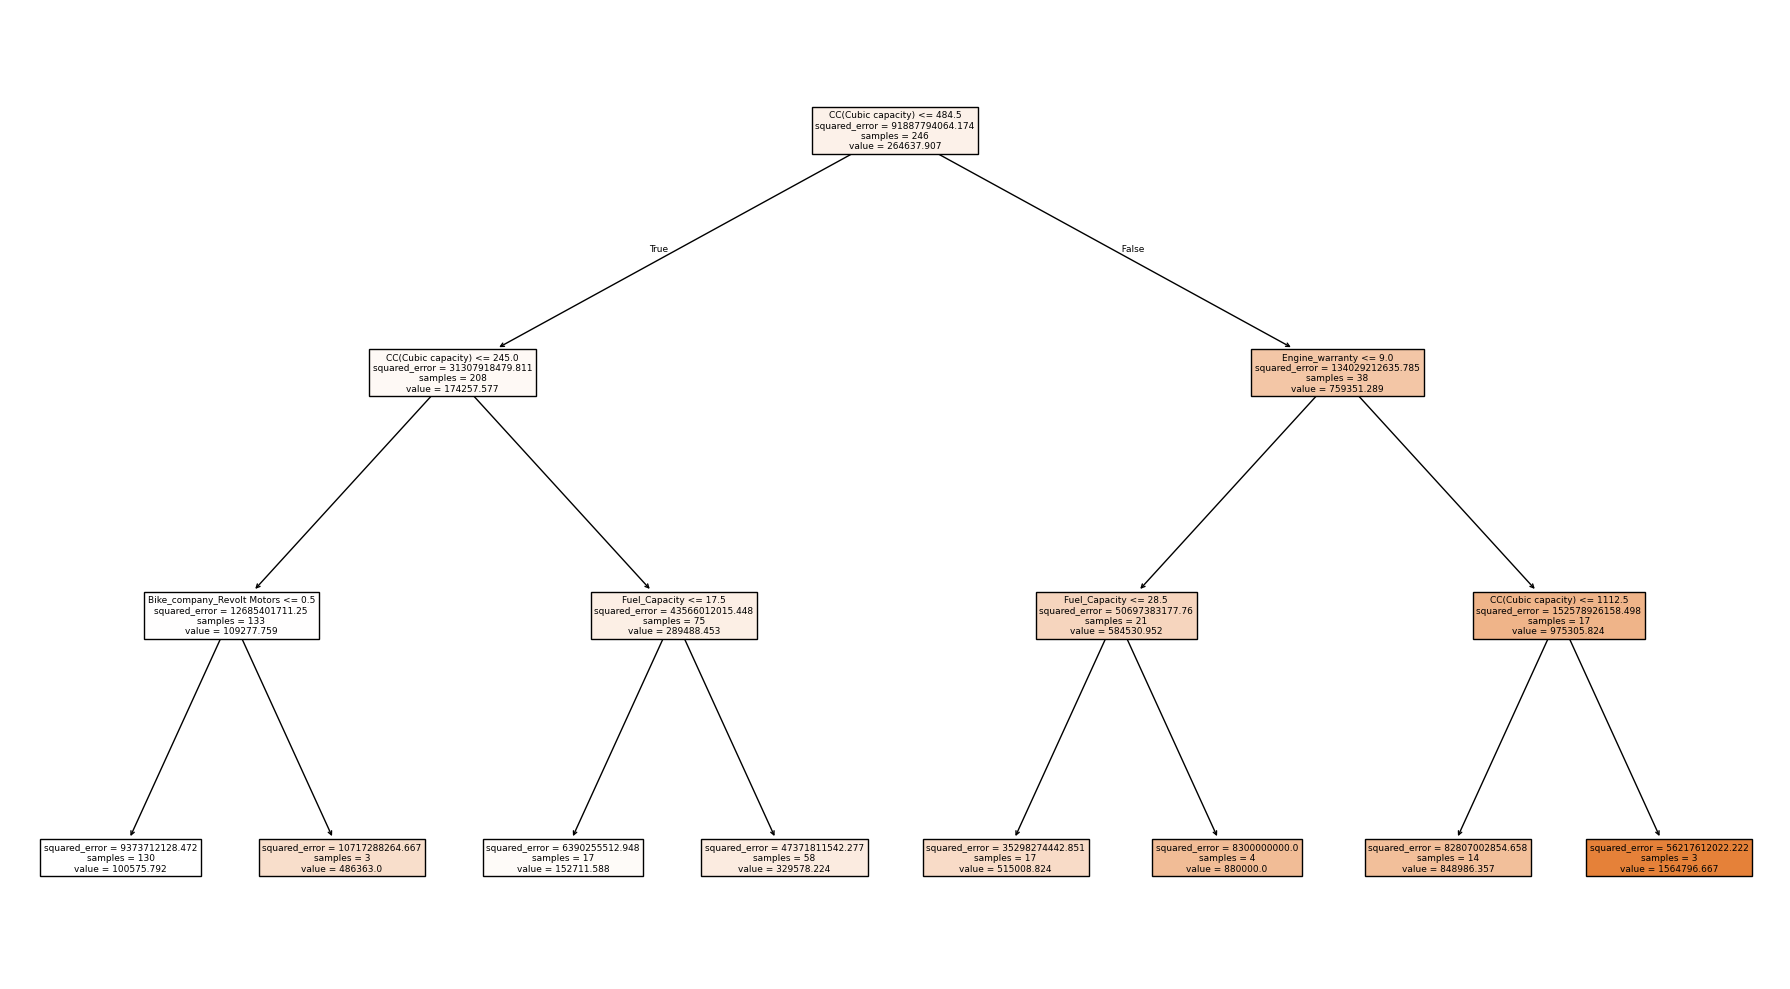

In [81]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [82]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=200,max_depth=5,max_leaf_nodes=25)
rfr.fit(X_train,y_train)
y_pred=rfr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 76391.0810469183
MSE : 17864684884.711056
RMSE: 133658.83766033227
R2  : 0.722969709277002


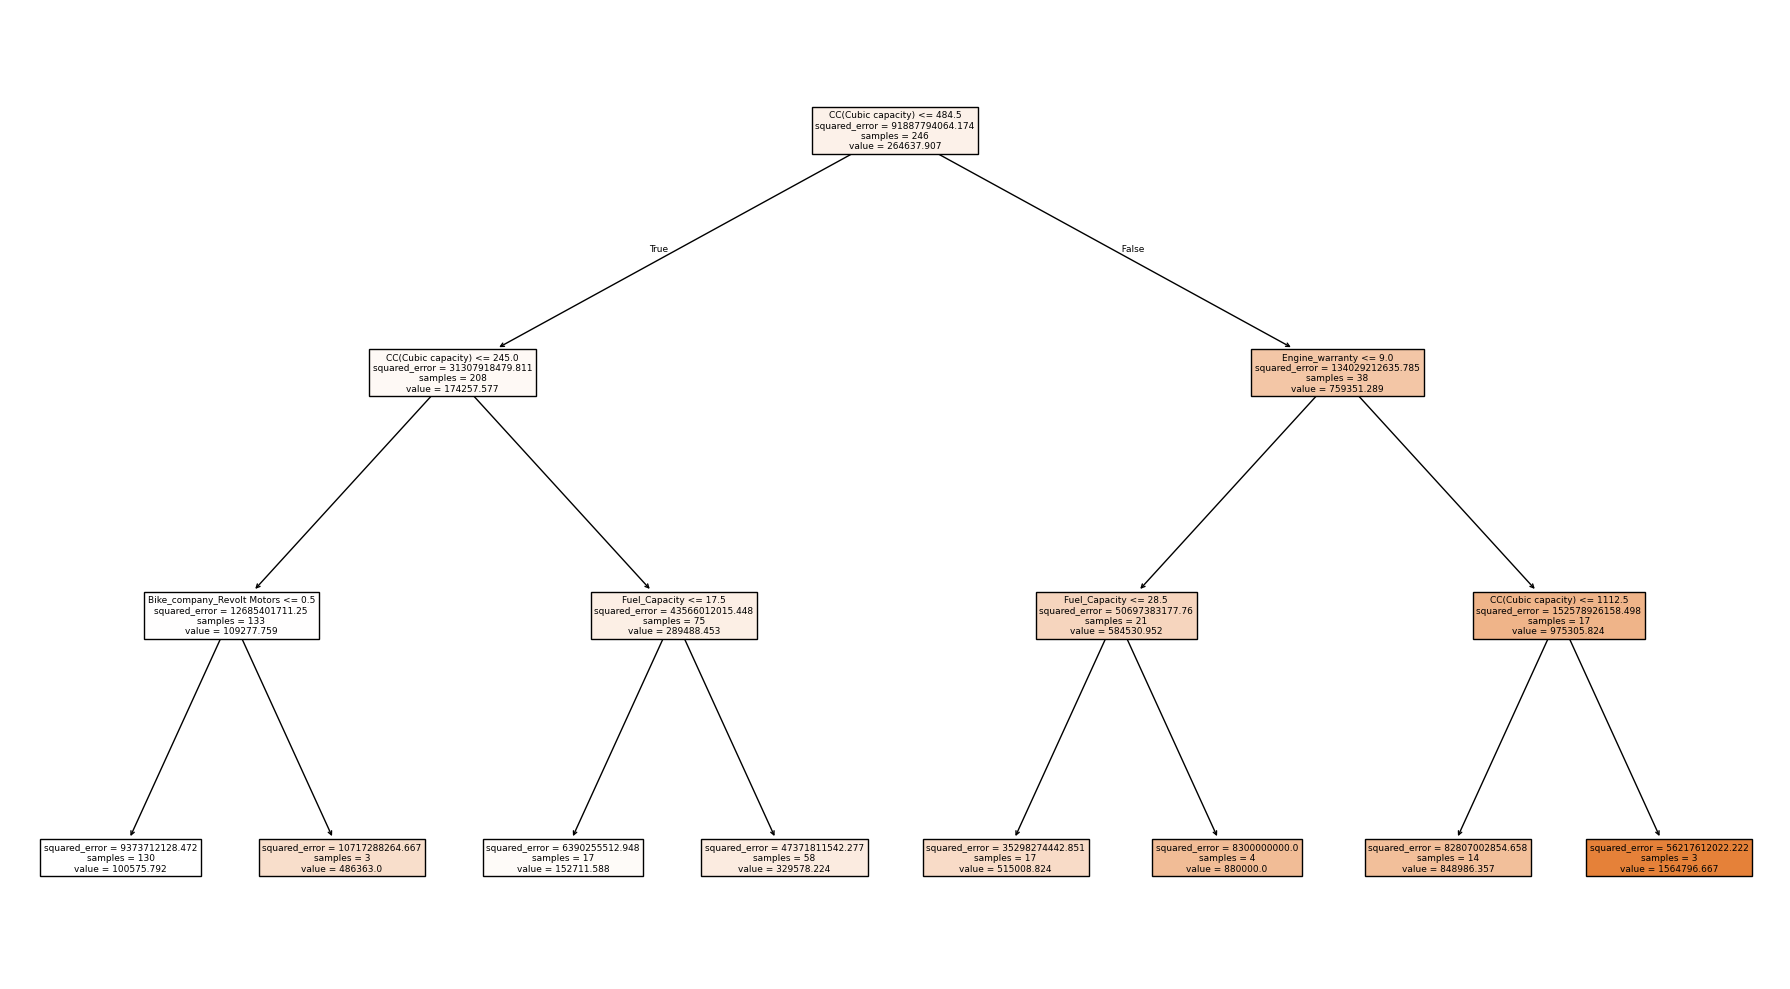

In [83]:
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [84]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, subsample=0.8)

gbr.fit(X_train,y_train)
y_pred=gbr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 64012.32112369467
MSE : 14077390735.392347
RMSE: 118648.18049760538
R2  : 0.7816998355574377


In [85]:
import xgboost as xgb
model1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 65191.82673891129
MSE : 14252675345.489746
RMSE: 119384.56912637306
R2  : 0.778981671380016


In [86]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
param_grid = {
    "C": [1, 2, 5, 10, 50, 100],
    "kernel": ["rbf", "linear"],
    "epsilon": [0.01, 0.1, 0.2, 0.3, 0.5]
}
svr = SVR()

grid_search = GridSearchCV(svr, param_grid, scoring="r2", cv=5)

grid_search.fit(X_train, y_train)
y_pred=grid_search.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 99212.38079886667
MSE : 33796585287.082184
RMSE: 183838.4760790901
R2  : 0.4759113912197951
